In [1]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Load Data

In [3]:
image_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
dataset_path = "./dataset"

dataset = datasets.ImageFolder(root=dataset_path, transform=image_transform)
len(dataset)

2300

In [6]:
class_names = dataset.classes
class_names

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [7]:
num_classes = len(dataset.classes)
num_classes

6

In [8]:
train_size = int(0.75*len(dataset))
val_size = len(dataset)-train_size

train_size, val_size

(1725, 575)

In [9]:
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [10]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [11]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [12]:
labels[2]

tensor(5)

In [13]:
images[2].shape

torch.Size([3, 224, 224])

In [14]:
images[2].permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.6051416].


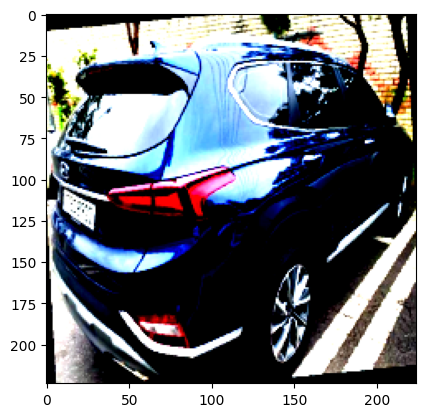

In [15]:
plt.imshow(images[2].permute(1,2,0))
plt.show()

#### Model 1: CNN

In [16]:
class CarClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1), #(16, 224, 224) =>in_channels=3(RGB),=>out_channels=16(feature map) 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (16, 112, 112) kernel_size=2, stride=2=> Reduce image into half
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (32, 56, 56)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1), #(16, 224, 224) 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (64, 28, 28)
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.network(x)
        return x

In [17]:
#instantiate the model, loss ftn, and optimizer

model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [18]:
def train_model(model, criterion, optimizer, epochs=5):
    start = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            #zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels) #output=>predicted labels

            # Backward pass
            loss.backward() #loss=>tensor
            optimizer.step()

            if (batch_num+1) % 10 ==0:
                print(f"Batch:{batch_num+1}, Epoch:{epoch+1}, Loss:{loss.item():0.2f}")

            running_loss += loss.item() * images.size(0) #images.size(0) is a batch size 
        
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/ {epochs}], Avg Loss: {epoch_loss:4f}")

        #Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
            print(f"*** Validation Accuracy: {100 * correct/ total:.2f}% ***")

    end = time.time()
    print(f"Execution time: {end-start} seconds")
    return all_labels, all_predictions

In [19]:
all_labels, all_predictions = train_model(model, criterion, optimizer, epochs=5)


Batch:10, Epoch:1, Loss:1.80
Batch:20, Epoch:1, Loss:1.79
Batch:30, Epoch:1, Loss:1.79
Batch:40, Epoch:1, Loss:1.79
Batch:50, Epoch:1, Loss:1.78
Epoch [1/ 5], Avg Loss: 1.996278
*** Validation Accuracy: 27.83% ***
Batch:10, Epoch:2, Loss:1.61
Batch:20, Epoch:2, Loss:1.46
Batch:30, Epoch:2, Loss:1.26
Batch:40, Epoch:2, Loss:1.37
Batch:50, Epoch:2, Loss:1.44
Epoch [2/ 5], Avg Loss: 1.506712
*** Validation Accuracy: 40.00% ***
Batch:10, Epoch:3, Loss:1.16
Batch:20, Epoch:3, Loss:1.32
Batch:30, Epoch:3, Loss:1.20
Batch:40, Epoch:3, Loss:1.34
Batch:50, Epoch:3, Loss:1.49
Epoch [3/ 5], Avg Loss: 1.310961
*** Validation Accuracy: 43.83% ***
Batch:10, Epoch:4, Loss:1.39
Batch:20, Epoch:4, Loss:1.25
Batch:30, Epoch:4, Loss:1.24
Batch:40, Epoch:4, Loss:1.30
Batch:50, Epoch:4, Loss:0.88
Epoch [4/ 5], Avg Loss: 1.218781
*** Validation Accuracy: 47.83% ***
Batch:10, Epoch:5, Loss:1.11
Batch:20, Epoch:5, Loss:0.99
Batch:30, Epoch:5, Loss:1.06
Batch:40, Epoch:5, Loss:1.07
Batch:50, Epoch:5, Loss:1.07

#### Model2: CNN with Regularization

In [20]:
class CarClassifierCNNWithRegularization(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1), #(16, 224, 224) =>in_channels=3(RGB),=>out_channels=16(feature map)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (16, 112, 112) kernel_size=2, stride=2=> Reduce image into half
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (32, 56, 56)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1), #(16, 224, 224)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (64, 28, 28)
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.network(x)
        return x

In [21]:
model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

pred, label = train_model(model, criterion, optimizer, epochs=5)

Batch:10, Epoch:1, Loss:1.82
Batch:20, Epoch:1, Loss:1.67
Batch:30, Epoch:1, Loss:1.60
Batch:40, Epoch:1, Loss:1.59
Batch:50, Epoch:1, Loss:1.36
Epoch [1/ 5], Avg Loss: 1.853404
*** Validation Accuracy: 36.70% ***
Batch:10, Epoch:2, Loss:1.71
Batch:20, Epoch:2, Loss:1.35
Batch:30, Epoch:2, Loss:1.54
Batch:40, Epoch:2, Loss:1.43
Batch:50, Epoch:2, Loss:1.35
Epoch [2/ 5], Avg Loss: 1.342961
*** Validation Accuracy: 44.52% ***
Batch:10, Epoch:3, Loss:1.37
Batch:20, Epoch:3, Loss:1.33
Batch:30, Epoch:3, Loss:1.11
Batch:40, Epoch:3, Loss:1.34
Batch:50, Epoch:3, Loss:1.01
Epoch [3/ 5], Avg Loss: 1.204588
*** Validation Accuracy: 50.96% ***
Batch:10, Epoch:4, Loss:0.91
Batch:20, Epoch:4, Loss:1.11
Batch:30, Epoch:4, Loss:1.08
Batch:40, Epoch:4, Loss:0.98
Batch:50, Epoch:4, Loss:1.23
Epoch [4/ 5], Avg Loss: 1.054370
*** Validation Accuracy: 52.70% ***
Batch:10, Epoch:5, Loss:0.83
Batch:20, Epoch:5, Loss:1.02
Batch:30, Epoch:5, Loss:0.85
Batch:40, Epoch:5, Loss:0.78
Batch:50, Epoch:5, Loss:1.06

##### Model 3: Transfer Learning using EfficientNet

In [22]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights="DEFAULT")

        for param in self.model.parameters():
            param.requires_grad = False
            
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )
    def forward(self, x):
        x=self.model(x)
        return x

In [24]:
model = CarClassifierEfficientNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

pred_1, label_1 = train_model(model, criterion, optimizer, epochs=10)

Batch:10, Epoch:1, Loss:1.75
Batch:20, Epoch:1, Loss:1.55
Batch:30, Epoch:1, Loss:1.49
Batch:40, Epoch:1, Loss:1.22
Batch:50, Epoch:1, Loss:1.34
Epoch [1/ 10], Avg Loss: 1.466110
*** Validation Accuracy: 54.09% ***
Batch:10, Epoch:2, Loss:1.22
Batch:20, Epoch:2, Loss:1.24
Batch:30, Epoch:2, Loss:1.12
Batch:40, Epoch:2, Loss:1.14
Batch:50, Epoch:2, Loss:0.97
Epoch [2/ 10], Avg Loss: 1.120912
*** Validation Accuracy: 60.17% ***
Batch:10, Epoch:3, Loss:0.89
Batch:20, Epoch:3, Loss:1.08
Batch:30, Epoch:3, Loss:1.00
Batch:40, Epoch:3, Loss:0.98
Batch:50, Epoch:3, Loss:0.96
Epoch [3/ 10], Avg Loss: 1.011504
*** Validation Accuracy: 62.09% ***
Batch:10, Epoch:4, Loss:0.96
Batch:20, Epoch:4, Loss:1.08
Batch:30, Epoch:4, Loss:0.78
Batch:40, Epoch:4, Loss:0.79
Batch:50, Epoch:4, Loss:1.02
Epoch [4/ 10], Avg Loss: 0.937178
*** Validation Accuracy: 67.13% ***
Batch:10, Epoch:5, Loss:0.94
Batch:20, Epoch:5, Loss:1.04
Batch:30, Epoch:5, Loss:0.91
Batch:40, Epoch:5, Loss:0.98
Batch:50, Epoch:5, Loss:

#### Model 4: Transfer Learning using ResNet

In [25]:
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.model = models.resnet50(weights="DEFAULT")
        # Freeze all layers except fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False

        #unfreeze layer4 and full connected layer
        for param in self.model.layer4.parameters():
            param.requires_grad = True

        #replace the fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )
    def forward(self, x):
        x = self.model(x)
        return x

In [26]:
model = CarClassifierResNet(num_classes=num_classes, dropout_rate=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.003)

labels, predictions = train_model(model, criterion, optimizer, epochs=10)

Batch:10, Epoch:1, Loss:1.01
Batch:20, Epoch:1, Loss:0.91
Batch:30, Epoch:1, Loss:0.53
Batch:40, Epoch:1, Loss:0.67
Batch:50, Epoch:1, Loss:0.76
Epoch [1/ 10], Avg Loss: 0.906163
*** Validation Accuracy: 64.70% ***
Batch:10, Epoch:2, Loss:0.64
Batch:20, Epoch:2, Loss:0.69
Batch:30, Epoch:2, Loss:0.42
Batch:40, Epoch:2, Loss:0.36
Batch:50, Epoch:2, Loss:0.71
Epoch [2/ 10], Avg Loss: 0.493575
*** Validation Accuracy: 73.39% ***
Batch:10, Epoch:3, Loss:0.55
Batch:20, Epoch:3, Loss:0.28
Batch:30, Epoch:3, Loss:0.19
Batch:40, Epoch:3, Loss:0.29
Batch:50, Epoch:3, Loss:0.45
Epoch [3/ 10], Avg Loss: 0.335979
*** Validation Accuracy: 77.91% ***
Batch:10, Epoch:4, Loss:0.11
Batch:20, Epoch:4, Loss:0.40
Batch:30, Epoch:4, Loss:0.18
Batch:40, Epoch:4, Loss:0.09
Batch:50, Epoch:4, Loss:0.73
Epoch [4/ 10], Avg Loss: 0.295287
*** Validation Accuracy: 78.78% ***
Batch:10, Epoch:5, Loss:0.38
Batch:20, Epoch:5, Loss:0.37
Batch:30, Epoch:5, Loss:0.14
Batch:40, Epoch:5, Loss:0.17
Batch:50, Epoch:5, Loss:

In [27]:
labels[:15], predictions[:15]

([np.int64(5),
  np.int64(4),
  np.int64(0),
  np.int64(0),
  np.int64(3),
  np.int64(1),
  np.int64(4),
  np.int64(2),
  np.int64(0),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(0),
  np.int64(5),
  np.int64(5)],
 [np.int64(5),
  np.int64(4),
  np.int64(0),
  np.int64(0),
  np.int64(4),
  np.int64(1),
  np.int64(4),
  np.int64(2),
  np.int64(0),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(0),
  np.int64(4),
  np.int64(3)])

In [28]:
from sklearn.metrics import classification_report

report = classification_report(labels, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.83      0.91      0.87       114
           1       0.72      0.77      0.74        91
           2       0.93      0.88      0.91       120
           3       0.85      0.66      0.74        77
           4       0.67      0.75      0.71        96
           5       0.80      0.74      0.77        77

    accuracy                           0.80       575
   macro avg       0.80      0.79      0.79       575
weighted avg       0.81      0.80      0.80       575



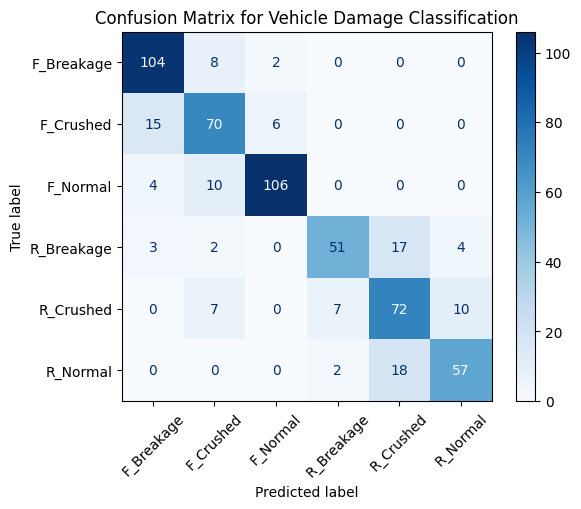

In [29]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

In [30]:
torch.save(model.state_dict(), "saved_model.pth")